## Setup

In [46]:
%load_ext autoreload
%autoreload 2
%aimport

%matplotlib inline 

import torch
import matplotlib.pyplot as plt
from einops import rearrange
import numpy as np

from bliss.catalog import TileCatalog, get_images_in_tiles
from bliss.encoder import Encoder


device = torch.device('cuda:0')
!echo $CUDA_VISIBLE_DEVICES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Modules to reload:
all-except-skipped

Modules to skip:

4


In [ ]:
from tqdm import tqdm
from collections import defaultdict
from case_studies.sdss_galaxies.plots.bliss_figures import set_rc_params, format_plot, CB_color_cycle

def compute_mag_bin_metrics(mag_bins, truth, pred):
    metrics_per_mag = defaultdict(lambda: torch.zeros(len(mag_bins)))

    # compute data for precision/recall/classification accuracy as a function of magnitude.
    for ii, (mag1, mag2) in tqdm(enumerate(mag_bins), total=len(mag_bins)):
        res = scene_metrics(truth, pred, mag_min=mag1, mag_max=mag2, slack=1.0)
        metrics_per_mag["precision"][ii] = res["precision"]
        metrics_per_mag["recall"][ii] = res["recall"]
        metrics_per_mag["f1"][ii] = res["f1"]
        metrics_per_mag["class_acc"][ii] = res["class_acc"]
        conf_matrix = res["conf_matrix"]
        metrics_per_mag["galaxy_acc"][ii] = conf_matrix[0, 0] / conf_matrix[0, :].sum().item()
        metrics_per_mag["star_acc"][ii] = conf_matrix[1, 1] / conf_matrix[1, :].sum().item()
        for k, v in res["counts"].items():
            metrics_per_mag[k][ii] = v

    return dict(metrics_per_mag)


def make_detection_figure(
    mags,
    data,
    xlims=(18, 24),
    ylims=(0.7, 1.05),
    ratio=1,
    where_step="mid",
    n_gap=50,
):
    # precision / recall / f1 score
    precision = data["precision"].numpy()
    recall = data["recall"].numpy()
    f1_score = data["f1"].numpy()
    tgcount = data["tgcount"].numpy()
    tscount = data["tscount"].numpy()
    egcount = data["egcount"].numpy()
    escount = data["escount"].numpy()
    # (1) precision / recall
    set_rc_params(tick_label_size=16, label_size=20)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 10), gridspec_kw={"height_ratios": [1, ratio]}, sharex=True
    )
    
    ymin = min(min(precision), min(recall))
    yticks = np.arange(np.round(ymin, 1), 1.1, 0.1)
    format_plot(ax2, xlabel=r"\rm magnitude cut", ylabel="metric", yticks=yticks)
    ax2.plot(mags[:, 1], recall, "-o", label=r"\rm recall")
    ax2.plot(mags[:, 1], precision, "-o", label=r"\rm precision")
    ax2.plot(mags[:, 1], f1_score, "-o", label=r"\rm f1 score")
    ax2.legend(loc="lower left", prop={"size": 16})
    ax2.set_xlim(xlims)
    ax2.set_ylim(ylims)
    ax2.yaxis.get_ticklocs(minor=True)
    ax2.minorticks_on()

    # setup histogram plot up top.
    c1 = CB_color_cycle[3]
    c2 = CB_color_cycle[4]
    ax1.step(mags[:, 1], tscount, label="truth stars", where=where_step, color=c2)
    ax1.step(mags[:, 1], escount, label="pred. stars", ls="--", where=where_step, color=c2)

    format_plot(ax1, ylabel=r"\rm counts")
    ax1.legend(loc="best", prop={"size": 16})
    plt.subplots_adjust(hspace=0)
    return fig

## Load Models

In [2]:
# load models
from hydra import compose, initialize
from hydra.utils import instantiate

with initialize(config_path="../../../case_studies/coadds/config"):
    cfg = compose("config", overrides=[])

In [3]:
location = instantiate(cfg.models.detection_encoder).to(device).eval()
# NOTE: change weight_checkpoint to the one in your output folder
location.load_state_dict(torch.load('./case_studies/coadds/models/single_encoder.pt', map_location=location.device)
)

encoder = Encoder(location.eval(), n_images_per_batch=10, n_rows_per_batch=15).to(device).eval()

In [4]:
location_coadd = instantiate(cfg.models.detection_encoder).to(device).eval()
location_coadd.load_state_dict(torch.load('./case_studies/coadds/models/coadd_encoder.pt', map_location=location_coadd.device)
)

encoder_coadd = Encoder(location_coadd.eval(), n_images_per_batch=10, n_rows_per_batch=15).to(device).eval()

In [5]:
location_coadd25 = instantiate(cfg.models.detection_encoder).to(device).eval()
location_coadd25.load_state_dict(torch.load('./case_studies/coadds/models/coadd_encoder_25.pt', map_location=location_coadd25.device)
)

encoder_coadd25 = Encoder(location_coadd25.eval(), n_images_per_batch=10, n_rows_per_batch=15).to(device).eval()

In [6]:
location_coadd50 = instantiate(cfg.models.detection_encoder).to(device).eval()
location_coadd50.load_state_dict(torch.load('./case_studies/coadds/models/coadd_encoder_50.pt', map_location=location_coadd50.device)
)

encoder_coadd50 = Encoder(location_coadd50.eval(), n_images_per_batch=10, n_rows_per_batch=15).to(device).eval()

## Load Coadd Dataset

In [7]:
with initialize(config_path="../../../case_studies/coadds/config"):
    cfg = compose("config", overrides=[])

In [8]:
# should be ONLY stars
cfg.datasets.galsim_blends_coadds.prior.galaxy_prob

0.0

In [9]:
cfg.datasets.galsim_blends_coadds.prior.n_dithers = 10

In [10]:
ds = instantiate(cfg.datasets.galsim_blends_coadds, batch_size=64, n_batches=100, num_workers=20)

In [11]:
from bliss.generate import generate
generate(ds, '/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.pt', '/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.png', 9, global_params=("background",))


Generating dataset: 100%|██████████| 100/100 [00:34<00:00,  2.87it/s]


In [12]:
cfg.datasets.galsim_blends_coadds.prior.n_dithers = 25
ds = instantiate(cfg.datasets.galsim_blends_coadds, batch_size=64, n_batches=100, num_workers=20)

from bliss.generate import generate
generate(ds, '/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.pt', '/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.png', 9, global_params=("background",))


Generating dataset: 100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


## Run Model on saved datset

In [13]:
sds = torch.load('/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset2.pt')
sds['images'].shape, sds['noisy'].shape, sds['n_sources'].shape

(torch.Size([6400, 1, 88, 88]),
 torch.Size([6400, 1, 88, 88]),
 torch.Size([6400, 10, 10]))

In [14]:
# format background (needs to be CONSTANT)
n_batches = sds['images'].shape[0]
slen = sds['images'].shape[-1]
background = rearrange(sds['background'], '1 h w -> 1 1 h w')
background = background.expand(n_batches, 1, slen, slen)

In [15]:
# run (single-exposure) model prediction 
tile_est = encoder.variational_mode(sds['noisy'], background)

Encoding ptiles: 640it [00:40, 15.72it/s]


In [28]:
sds10 = torch.load('/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset10.pt')

# format background (needs to be CONSTANT)
n_batches = sds10['images'].shape[0]
slen = sds10['images'].shape[-1]
background = rearrange(sds10['background'], '1 h w -> 1 1 h w')
background = background.expand(n_batches, 1, slen, slen)

# run (coadd) model prediction 
tile_est_coadd = encoder_coadd.variational_mode(sds10['images'], background)

Encoding ptiles: 640it [00:40, 15.91it/s]


In [17]:
sds25 = torch.load('/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset25.pt')
sds25['images'].shape, sds25['noisy'].shape, sds25['n_sources'].shape

# format background (needs to be CONSTANT)
n_batches = sds25['images'].shape[0]
slen = sds25['images'].shape[-1]
background = rearrange(sds25['background'], '1 h w -> 1 1 h w')
background = background.expand(n_batches, 1, slen, slen)

# run (coadd) model prediction 
tile_est_coadd25 = encoder_coadd25.variational_mode(sds25['images'], background)

Encoding ptiles: 640it [00:41, 15.54it/s]


In [18]:
sds50 = torch.load('/home/wmallory/bliss/case_studies/coadds/output/coadd_dataset25.pt')
sds50['images'].shape, sds50['noisy'].shape, sds50['n_sources'].shape

# format background (needs to be CONSTANT)
n_batches = sds50['images'].shape[0]
slen = sds50['images'].shape[-1]
background = rearrange(sds50['background'], '1 h w -> 1 1 h w')
background = background.expand(n_batches, 1, slen, slen)

# run (coadd) model prediction 
tile_est_coadd50 = encoder_coadd50.variational_mode(sds50['images'], background)

Encoding ptiles: 640it [00:40, 15.82it/s]


In [202]:
def sample_dataset(n, dataset):
    n_batches = dataset["images"].shape[0]
    weights = torch.tensor([1/n_batches]*n_batches, dtype=torch.float)
    sample_index = torch.multinomial(weights, n, replacement=True)
    #samp = sds[sample_index]

    sample_sds = {}
    for k, v in dataset.items(): 
        if k == "background":
            sample_sds[k] = dataset[k]
        else:
            sample_sds[k] = dataset[k][sample_index]
    
    return sample_sds

In [203]:
sample_sds = sample_dataset(n = 400, dataset = sds)


In [153]:
def get_bin_sample_metrics(dataset, encoder, mag_cuts):
    #' encoder: choose from encoder (single exposure), encoder_coadd (d=10), 
    # encoder_coadd25 (d=25), and encoder_coadd50 (d=50)      
    n_batches = dataset['images'].shape[0]
    slen = dataset['images'].shape[-1]
    background = rearrange(dataset['background'], '1 h w -> 1 1 h w')
    background = background.expand(n_batches, 1, slen, slen)
    tile_est_coadd = encoder.variational_mode(dataset['images'], background)

    sample_catalog_dict = {
        "locs": dataset["locs"],
        "star_log_fluxes": dataset["star_log_fluxes"],
        "galaxy_bools": dataset["galaxy_bools"],
        "n_sources": dataset["n_sources"],
        "star_fluxes": dataset['star_fluxes']
    }
    true_sample_tile_catalog = TileCatalog(4, sample_catalog_dict)
    sample_truth = true_sample_tile_catalog.to_full_params()

    sample_est = tile_est_coadd.cpu().to_full_params() # full estimated catalog from single exposure model
    sample_est['galaxy_bools'] = torch.zeros(sample_est.batch_size, sample_est.max_sources, 1) # only stars, did not train classification encoder

    from bliss.reporting import DetectionMetrics
    sample_metrics = DetectionMetrics()(sample_truth, sample_est)

    from bliss.datasets.sdss import convert_flux_to_mag
    sample_truth['mags'] = torch.zeros_like(sample_truth['star_fluxes'])
    for ii in range(len(sample_truth.n_sources)):
        n_sources = sample_truth.n_sources[ii].item()
        sample_truth['mags'][ii, :n_sources] = convert_flux_to_mag(sample_truth['star_fluxes'][ii, :n_sources])

    sample_est['mags'] = torch.zeros_like(sample_est['star_fluxes'])
    for ii in range(len(sample_est.n_sources)):
        n_sources = sample_est.n_sources[ii].item()
        sample_est['mags'][ii, :n_sources] = convert_flux_to_mag(sample_est['star_fluxes'][ii, :n_sources])
    
    return torch.tensor([sample_metrics['f1'], sample_metrics['precision'], sample_metrics['recall']]), compute_mag_bin_metrics(mag_cuts, sample_truth, sample_est)

In [ ]:

mag_cuts2 = torch.arange(18, 25, 0.5)
mag_cuts1 = torch.full_like(mag_cuts2, fill_value=-np.inf)
mag_cuts = torch.column_stack((mag_cuts1, mag_cuts2))

In [188]:
overall_metrics, binned_metrics = get_bin_sample_metrics(dataset=sample_sds, encoder=encoder_coadd, mag_cuts=mag_cuts)

Encoding ptiles: 40it [00:02, 16.04it/s]
100%|██████████| 14/14 [00:19<00:00,  1.42s/it]


In [191]:
torch.cat((overall_metrics.unsqueeze(0), overall_metrics.unsqueeze(0)), dim=0)

tensor([[0.9426, 0.9477, 0.9376],
        [0.9426, 0.9477, 0.9376]])

In [179]:
binned_metrics["precision"]
binned_metrics["recall"]


{'precision': tensor([0.9474, 0.9434, 0.9442, 0.9462, 0.9517, 0.9468, 0.9496, 0.9514, 0.9553,
         0.9475, 0.9448, 0.9477, 0.9477, 0.9477]),
 'recall': tensor([0.9836, 0.9882, 0.9815, 0.9795, 0.9789, 0.9807, 0.9775, 0.9776, 0.9691,
         0.9596, 0.9390, 0.9376, 0.9376, 0.9376]),
 'f1': tensor([0.9651, 0.9653, 0.9625, 0.9626, 0.9652, 0.9635, 0.9633, 0.9643, 0.9622,
         0.9535, 0.9419, 0.9426, 0.9426, 0.9426]),
 'class_acc': tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'galaxy_acc': tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
 'star_acc': tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'tgcount': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'tscount': tensor([ 122.,  170.,  216.,  292.,  380.,  467.,  578.,  714.,  874., 1115.,
         1409., 1411., 1411., 1411.]),
 'egcount': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'escount': tensor([ 114.,  159.,  2

In [206]:
def bootstrap_images(n_boot, n_images, mag_cuts, dataset, encoder):
    sampled_overall_metrics = torch.empty(size=(n_boot, 3))
    sampled_binned_precision = torch.empty(size=(n_boot, mag_cuts.shape[0]))
    sampled_binned_recall = torch.empty(size=(n_boot, mag_cuts.shape[0]))
    for i in range(n_boot): 
        sample_sds = sample_dataset(n = n_images, dataset = sds)
        overall_metrics, binned_metrics = get_bin_sample_metrics(dataset=sample_sds, encoder=encoder_coadd, mag_cuts=mag_cuts)
        sampled_overall_metrics[i] = overall_metrics
        sampled_binned_precision[i] = binned_metrics["precision"]
        sampled_binned_recall[i] = binned_metrics["recall"] 
    return sampled_overall_metrics, sampled_binned_precision, sampled_binned_recall
        


In [207]:
boot_overall_metrics, boot_binned_precision, boot_binned_recall = bootstrap_images(n_boot = 4, n_images = 100, mag_cuts=mag_cuts, dataset=sds, encoder=encoder_coadd)

Encoding ptiles: 10it [00:00, 15.56it/s]
100%|██████████| 14/14 [00:04<00:00,  2.96it/s]
Encoding ptiles: 10it [00:00, 16.31it/s]
100%|██████████| 14/14 [00:04<00:00,  3.13it/s]
Encoding ptiles: 10it [00:00, 15.42it/s]
100%|██████████| 14/14 [00:03<00:00,  3.51it/s]
Encoding ptiles: 10it [00:00, 16.10it/s]
100%|██████████| 14/14 [00:04<00:00,  3.41it/s]


In [210]:
boot_overall_metrics

tensor([[0.9498, 0.9469, 0.9528],
        [0.9297, 0.9367, 0.9228],
        [0.9553, 0.9607, 0.9500],
        [0.9646, 0.9690, 0.9601]])

In [211]:
boot_binned_precision


tensor([[0.9286, 0.9211, 0.9231, 0.9254, 0.9348, 0.9292, 0.9375, 0.9360, 0.9415,
         0.9339, 0.9439, 0.9469, 0.9469, 0.9469],
        [0.9500, 0.8966, 0.9375, 0.9403, 0.9481, 0.9439, 0.9398, 0.9333, 0.9256,
         0.9305, 0.9399, 0.9367, 0.9367, 0.9367],
        [0.9375, 0.9286, 0.9231, 0.9474, 0.9610, 0.9700, 0.9697, 0.9682, 0.9655,
         0.9577, 0.9582, 0.9607, 0.9607, 0.9607],
        [0.9200, 0.9333, 0.9512, 0.9412, 0.9429, 0.9570, 0.9609, 0.9695, 0.9604,
         0.9603, 0.9676, 0.9690, 0.9690, 0.9690]])

## Bootstrap for 1, 10, 25, 50

1: sds / encoder
10: sds10 / encoder_coadd
25: sds25 / encoder_coadd25
50: sds50 / encoder_coadd50

In [212]:
boot_overall_metrics, boot_binned_precision, boot_binned_recall = bootstrap_images(n_boot = 1000, n_images = 6400, mag_cuts=mag_cuts, dataset=sds, encoder=encoder)

Encoding ptiles: 640it [00:40, 15.88it/s]
  7%|▋         | 1/14 [00:12<02:36, 12.04s/it]

In [ ]:
boot_overall_metrics10, boot_binned_precision10, boot_binned_recall10 = bootstrap_images(n_boot = 1000, n_images = 6400, mag_cuts=mag_cuts, dataset=sds10, encoder=encoder_coadd)

In [ ]:
boot_overall_metrics25, boot_binned_precision25, boot_binned_recall25 = bootstrap_images(n_boot = 1000, n_images = 6400, mag_cuts=mag_cuts, dataset=sds25, encoder=encoder_coadd25)

In [ ]:
boot_overall_metrics50, boot_binned_precision50, boot_binned_recall50 = bootstrap_images(n_boot = 1000, n_images = 6400, mag_cuts=mag_cuts, dataset=sds50, encoder=encoder_coadd50)

## Metric on prediction compared to truth

In [19]:
# load true catalog
catalog_dict = {
    "locs": sds["locs"],
    "star_log_fluxes": sds["star_log_fluxes"],
    "galaxy_bools": sds["galaxy_bools"],
    "n_sources": sds["n_sources"],
    "star_fluxes": sds['star_fluxes']
}

In [20]:
true_tile_catalog = TileCatalog(4, catalog_dict)
truth = true_tile_catalog.to_full_params()

## Encoder

In [21]:
est = tile_est.cpu().to_full_params() # full estimated catalog from single exposure model
est['galaxy_bools'] = torch.zeros(est.batch_size, est.max_sources, 1) # only stars, did not train classification encoder

### Simple metrics

In [22]:
# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est)

In [23]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.8770), tensor(0.9307), tensor(0.8292))

In [29]:
# load true catalog
catalog_dict10 = {
    "locs": sds10["locs"],
    "star_log_fluxes": sds10["star_log_fluxes"],
    "galaxy_bools": sds10["galaxy_bools"],
    "n_sources": sds10["n_sources"],
    "star_fluxes": sds10['star_fluxes']
}
true_tile_catalog10 = TileCatalog(4, catalog_dict10)
truth10 = true_tile_catalog10.to_full_params()

est10 = tile_est_coadd.cpu().to_full_params() # full estimated catalog from single exposure model
est10['galaxy_bools'] = torch.zeros(est10.batch_size, est10.max_sources, 1) # only stars, did not train classification encoder

# encoder
from bliss.reporting import DetectionMetrics
metrics10 = DetectionMetrics()(truth10, est10)
metrics10['f1'], metrics10['precision'], metrics10['recall']

(tensor(0.9435), tensor(0.9541), tensor(0.9331))

In [24]:
# load true catalog
catalog_dict25 = {
    "locs": sds25["locs"],
    "star_log_fluxes": sds25["star_log_fluxes"],
    "galaxy_bools": sds25["galaxy_bools"],
    "n_sources": sds25["n_sources"],
    "star_fluxes": sds25['star_fluxes']
}
true_tile_catalog25 = TileCatalog(4, catalog_dict25)
truth25 = true_tile_catalog25.to_full_params()

est25 = tile_est_coadd25.cpu().to_full_params() # full estimated catalog from single exposure model
est25['galaxy_bools'] = torch.zeros(est25.batch_size, est25.max_sources, 1) # only stars, did not train classification encoder

# encoder
from bliss.reporting import DetectionMetrics
metrics25 = DetectionMetrics()(truth25, est25)
metrics25['f1'], metrics25['precision'], metrics25['recall']

(tensor(0.9454), tensor(0.9722), tensor(0.9200))

In [25]:
# load true catalog
catalog_dict50 = {
    "locs": sds50["locs"],
    "star_log_fluxes": sds50["star_log_fluxes"],
    "galaxy_bools": sds50["galaxy_bools"],
    "n_sources": sds50["n_sources"],
    "star_fluxes": sds50['star_fluxes']
}
true_tile_catalog50 = TileCatalog(4, catalog_dict50)
truth50 = true_tile_catalog50.to_full_params()

est50 = tile_est_coadd50.cpu().to_full_params() # full estimated catalog from single exposure model
est50['galaxy_bools'] = torch.zeros(est50.batch_size, est50.max_sources, 1) # only stars, did not train classification encoder

# encoder
from bliss.reporting import DetectionMetrics
metrics50 = DetectionMetrics()(truth50, est50)
metrics50['f1'], metrics50['precision'], metrics50['recall']

(tensor(0.9519), tensor(0.9582), tensor(0.9457))

## Flux prediction

In [33]:
from bliss.reporting import match_by_locs

In [34]:
# encoder
true_plocs = truth.plocs
est_plocs = est.plocs

In [58]:
# obtain fluxes of matches
true_fluxes = []
est_fluxes = [] 
for ii in range(true_plocs.shape[0]):
    n_sources1, n_sources2 = truth.n_sources[ii].item(), est.n_sources[ii].item()
    if n_sources1 > 0 and n_sources2 > 0:
        plocs1 = true_plocs[ii]
        plocs2 = est_plocs[ii]
        mtrue, mest, dkeep, avg_distance = match_by_locs(plocs1, plocs2)
        tp = len(plocs2[mest][dkeep])  # n_matches
        
        fluxes1 = truth['star_fluxes'][ii][mtrue][dkeep]
        fluxes2 = est['star_fluxes'][ii][mest][dkeep]
        for jj in range(tp):
            flux1 = fluxes1[jj].item()
            flux2 = fluxes2[jj].item()
            assert flux1 > 0 and flux2 > 0
            true_fluxes.append(flux1)
            est_fluxes.append(flux2)

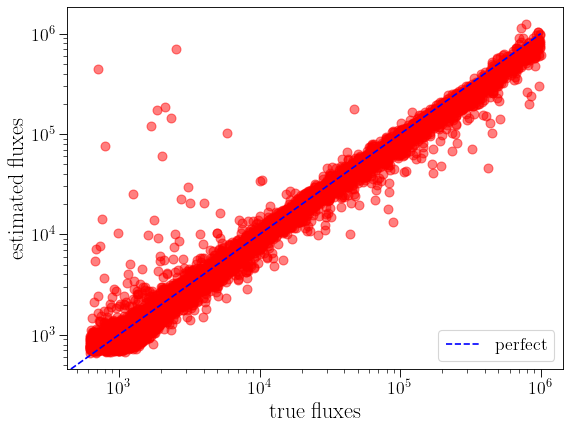

In [64]:
from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)
plt.scatter(true_fluxes, est_fluxes, marker='o', color='r', alpha=0.5)
plt.plot([0, 1e6], [0, 1e6], 'b--', label='perfect')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('true fluxes')
plt.ylabel('estimated fluxes')
plt.legend(loc="lower right",prop={"size": 16})

In [71]:
import pandas as pd
d = {'true': true_fluxes, 'est': est_fluxes}
fluxes = pd.DataFrame(d)

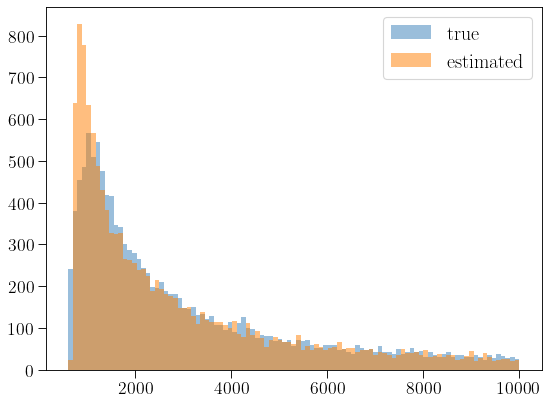

In [81]:
from matplotlib import pyplot
figure(figsize=(8, 6), dpi=80)
bins = np.linspace(600, 10000, 100)
pyplot.hist(fluxes['true'], bins, alpha=0.5, label='true')
pyplot.hist(fluxes['est'], bins, alpha=0.5, label='estimated')
pyplot.legend(loc='upper right')
pyplot.show()

In [75]:
max(fluxes['true'])


997155.0

## Add magnitude to truth and estimated catalog

In [26]:
## Single
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
truth['mags'] = torch.zeros_like(truth['star_fluxes'])
for ii in range(len(truth.n_sources)):
    n_sources = truth.n_sources[ii].item()
    truth['mags'][ii, :n_sources] = convert_flux_to_mag(truth['star_fluxes'][ii, :n_sources])

In [27]:
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
est['mags'] = torch.zeros_like(est['star_fluxes'])
for ii in range(len(est.n_sources)):
    n_sources = est.n_sources[ii].item()
    est['mags'][ii, :n_sources] = convert_flux_to_mag(est['star_fluxes'][ii, :n_sources])

In [30]:
## d = 10
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
truth10['mags'] = torch.zeros_like(truth10['star_fluxes'])
for ii in range(len(truth10.n_sources)):
    n_sources = truth10.n_sources[ii].item()
    truth10['mags'][ii, :n_sources] = convert_flux_to_mag(truth10['star_fluxes'][ii, :n_sources])

est10['mags'] = torch.zeros_like(est10['star_fluxes'])
for ii in range(len(est10.n_sources)):
    n_sources = est10.n_sources[ii].item()
    est10['mags'][ii, :n_sources] = convert_flux_to_mag(est10['star_fluxes'][ii, :n_sources])

In [31]:
## d = 25
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
truth25['mags'] = torch.zeros_like(truth25['star_fluxes'])
for ii in range(len(truth25.n_sources)):
    n_sources = truth25.n_sources[ii].item()
    truth25['mags'][ii, :n_sources] = convert_flux_to_mag(truth25['star_fluxes'][ii, :n_sources])

est25['mags'] = torch.zeros_like(est25['star_fluxes'])
for ii in range(len(est25.n_sources)):
    n_sources = est25.n_sources[ii].item()
    est25['mags'][ii, :n_sources] = convert_flux_to_mag(est25['star_fluxes'][ii, :n_sources])

In [32]:
## d = 50
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
truth50['mags'] = torch.zeros_like(truth50['star_fluxes'])
for ii in range(len(truth50.n_sources)):
    n_sources = truth50.n_sources[ii].item()
    truth50['mags'][ii, :n_sources] = convert_flux_to_mag(truth50['star_fluxes'][ii, :n_sources])

est50['mags'] = torch.zeros_like(est50['star_fluxes'])
for ii in range(len(est50.n_sources)):
    n_sources = est50.n_sources[ii].item()
    est50['mags'][ii, :n_sources] = convert_flux_to_mag(est50['star_fluxes'][ii, :n_sources])

In [33]:
# first check scene_metrics works for one bin 
from bliss.reporting import scene_metrics
import numpy as np

In [34]:
results = scene_metrics(truth, est, mag_min=-np.inf, mag_max=18)

In [35]:
results10 = scene_metrics(truth10, est10, mag_min=-np.inf, mag_max=18)

In [36]:
results25 = scene_metrics(truth25, est25, mag_min=-np.inf, mag_max=18)

In [37]:
results50 = scene_metrics(truth50, est50, mag_min=-np.inf, mag_max=18)

In [38]:
from tqdm import tqdm
from collections import defaultdict
from case_studies.sdss_galaxies.plots.bliss_figures import set_rc_params, format_plot, CB_color_cycle

def compute_mag_bin_metrics(mag_bins, truth, pred):
    metrics_per_mag = defaultdict(lambda: torch.zeros(len(mag_bins)))

    # compute data for precision/recall/classification accuracy as a function of magnitude.
    for ii, (mag1, mag2) in tqdm(enumerate(mag_bins), total=len(mag_bins)):
        res = scene_metrics(truth, pred, mag_min=mag1, mag_max=mag2, slack=1.0)
        metrics_per_mag["precision"][ii] = res["precision"]
        metrics_per_mag["recall"][ii] = res["recall"]
        metrics_per_mag["f1"][ii] = res["f1"]
        metrics_per_mag["class_acc"][ii] = res["class_acc"]
        conf_matrix = res["conf_matrix"]
        metrics_per_mag["galaxy_acc"][ii] = conf_matrix[0, 0] / conf_matrix[0, :].sum().item()
        metrics_per_mag["star_acc"][ii] = conf_matrix[1, 1] / conf_matrix[1, :].sum().item()
        for k, v in res["counts"].items():
            metrics_per_mag[k][ii] = v

    return dict(metrics_per_mag)


def make_detection_figure(
    mags,
    data,
    xlims=(18, 24),
    ylims=(0.7, 1.05),
    ratio=1,
    where_step="mid",
    n_gap=50,
):
    # precision / recall / f1 score
    precision = data["precision"].numpy()
    recall = data["recall"].numpy()
    f1_score = data["f1"].numpy()
    tgcount = data["tgcount"].numpy()
    tscount = data["tscount"].numpy()
    egcount = data["egcount"].numpy()
    escount = data["escount"].numpy()
    # (1) precision / recall
    set_rc_params(tick_label_size=16, label_size=20)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 10), gridspec_kw={"height_ratios": [1, ratio]}, sharex=True
    )
    
    ymin = min(min(precision), min(recall))
    yticks = np.arange(np.round(ymin, 1), 1.1, 0.1)
    format_plot(ax2, xlabel=r"\rm magnitude cut", ylabel="metric", yticks=yticks)
    ax2.plot(mags[:, 1], recall, "-o", label=r"\rm recall")
    ax2.plot(mags[:, 1], precision, "-o", label=r"\rm precision")
    ax2.plot(mags[:, 1], f1_score, "-o", label=r"\rm f1 score")
    ax2.legend(loc="lower left", prop={"size": 16})
    ax2.set_xlim(xlims)
    ax2.set_ylim(ylims)
    ax2.yaxis.get_ticklocs(minor=True)
    ax2.minorticks_on()

    # setup histogram plot up top.
    c1 = CB_color_cycle[3]
    c2 = CB_color_cycle[4]
    ax1.step(mags[:, 1], tscount, label="truth stars", where=where_step, color=c2)
    ax1.step(mags[:, 1], escount, label="pred. stars", ls="--", where=where_step, color=c2)

    format_plot(ax1, ylabel=r"\rm counts")
    ax1.legend(loc="best", prop={"size": 16})
    plt.subplots_adjust(hspace=0)
    return fig

In [39]:
mag_cuts2 = torch.arange(18, 25, 0.5)
mag_cuts1 = torch.full_like(mag_cuts2, fill_value=-np.inf)
mag_cuts = torch.column_stack((mag_cuts1, mag_cuts2))

In [40]:
data = compute_mag_bin_metrics(mag_cuts, truth, est)

100%|██████████| 14/14 [05:14<00:00, 22.47s/it]


In [41]:
data10 = compute_mag_bin_metrics(mag_cuts, truth10, est10)

100%|██████████| 14/14 [05:02<00:00, 21.59s/it]


In [42]:
data25 = compute_mag_bin_metrics(mag_cuts, truth25, est25)

100%|██████████| 14/14 [04:47<00:00, 20.55s/it]


In [43]:
data50 = compute_mag_bin_metrics(mag_cuts, truth50, est50)

100%|██████████| 14/14 [05:00<00:00, 21.48s/it]


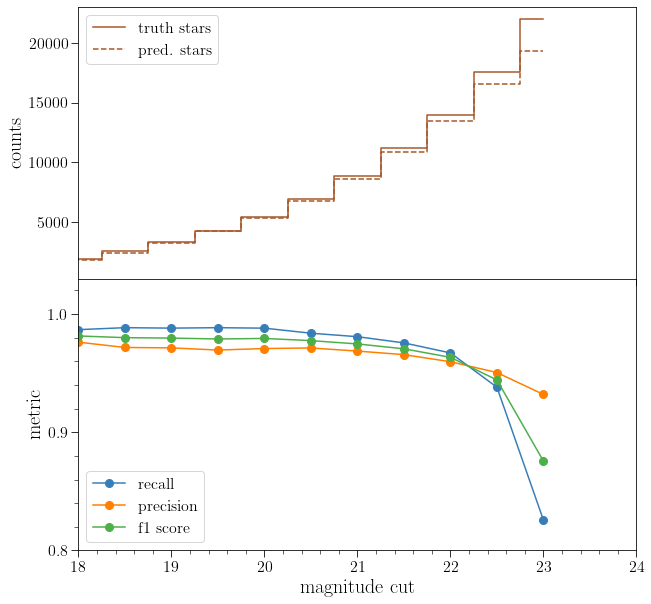

In [45]:
#fig = make_detection_figure(mag_cuts, data, ylims=(0.8, 1.03), n_gap=10)

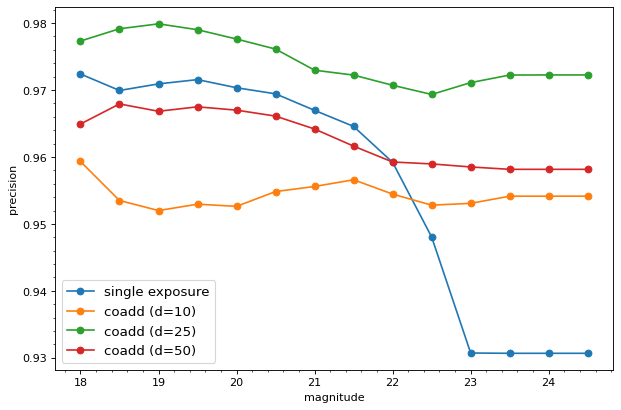

In [50]:
from matplotlib.pyplot import figure

figure(figsize=(9, 6), dpi=80)
plt.plot(mag_cuts[:, 1], data['precision'], "-o", label=r"\rm single exposure")
plt.plot(mag_cuts[:, 1], data10['precision'], "-o", label=r"\rm coadd (d=10)")
plt.plot(mag_cuts[:, 1], data25['precision'], "-o", label=r"\rm coadd (d=25)")
plt.plot(mag_cuts[:, 1], data50['precision'], "-o", label=r"\rm coadd (d=50)")
plt.xlabel('\rm magnitude')
plt.ylabel('\rm precision')
plt.legend(loc="lower left", prop={"size": 12})
plt.minorticks_on()

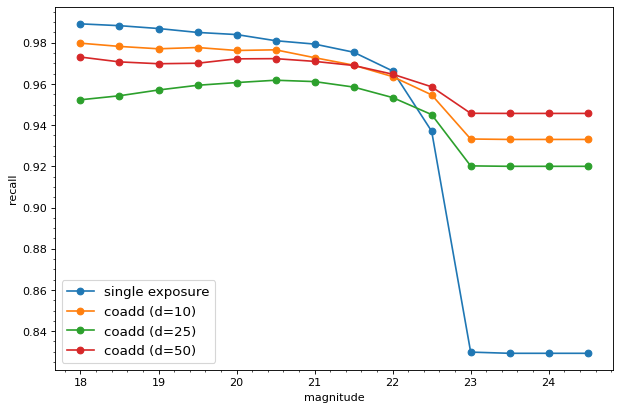

In [51]:
from matplotlib.pyplot import figure

figure(figsize=(9, 6), dpi=80)
plt.plot(mag_cuts[:, 1], data['recall'], "-o", label=r"\rm single exposure")
plt.plot(mag_cuts[:, 1], data10['recall'], "-o", label=r"\rm coadd (d=10)")
plt.plot(mag_cuts[:, 1], data25['recall'], "-o", label=r"\rm coadd (d=25)")
plt.plot(mag_cuts[:, 1], data50['recall'], "-o", label=r"\rm coadd (d=50)")
plt.xlabel('\rm magnitude')
plt.ylabel('\rm recall')
plt.legend(loc="lower left", prop={"size": 12})
plt.minorticks_on()

In [61]:
data

{'precision': tensor([0.9724, 0.9699, 0.9709, 0.9716, 0.9703, 0.9694, 0.9670, 0.9646, 0.9592,
         0.9480, 0.9307, 0.9307, 0.9307, 0.9307]),
 'recall': tensor([0.9892, 0.9883, 0.9869, 0.9850, 0.9840, 0.9810, 0.9793, 0.9754, 0.9663,
         0.9371, 0.8298, 0.8292, 0.8292, 0.8292]),
 'f1': tensor([0.9807, 0.9790, 0.9788, 0.9782, 0.9771, 0.9752, 0.9731, 0.9700, 0.9627,
         0.9425, 0.8774, 0.8770, 0.8770, 0.8770]),
 'class_acc': tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'galaxy_acc': tensor([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
 'star_acc': tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'tgcount': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'tscount': tensor([ 1939.,  2562.,  3361.,  4404.,  5682.,  7160.,  9015., 11272., 14198.,
         17803., 22130., 22150., 22150., 22150.]),
 'egcount': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'escount': tensor([ 1

## Coadd decoder -- OLD CODE BUT DON'T DELETE YET

In [46]:
## Get Full Catalogs

est_coadd = tile_est_coadd.cpu().to_full_params() # full estimated catalog from single exposure model

# parameters are now per image
est_coadd.plocs.shape

est_coadd['galaxy_bools'] = torch.zeros(est_coadd.batch_size, est_coadd.max_sources, 1) # only stars, did not train classification encoder



In [47]:
## Simple metrics

# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est_coadd)

In [48]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.9445), tensor(0.9557), tensor(0.9335))

In [49]:
est_coadd_plocs = est_coadd.plocs
# obtain fluxes of matches
true_fluxes = []
est_coadd_fluxes = [] 
for ii in range(true_plocs.shape[0]):
    n_sources1, n_sources2 = truth.n_sources[ii].item(), est_coadd.n_sources[ii].item()
    if n_sources1 > 0 and n_sources2 > 0:
        plocs1 = true_plocs[ii]
        plocs2 = est_coadd_plocs[ii]
        mtrue, mest, dkeep, avg_distance = match_by_locs(plocs1, plocs2)
        tp = len(plocs2[mest][dkeep])  # n_matches
        
        fluxes1 = truth['star_fluxes'][ii][mtrue][dkeep]
        fluxes2 = est_coadd['star_fluxes'][ii][mest][dkeep]
        for jj in range(tp):
            flux1 = fluxes1[jj].item()
            flux2 = fluxes2[jj].item()
            assert flux1 > 0 and flux2 > 0
            true_fluxes.append(flux1)
            est_coadd_fluxes.append(flux2)

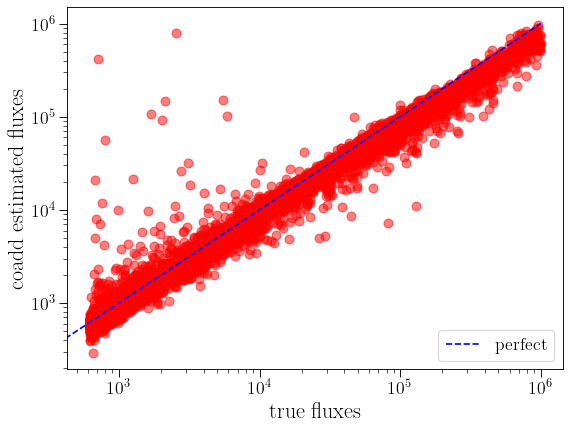

In [57]:
from matplotlib.pyplot import figure

figure(figsize=(8, 6), dpi=80)
plt.scatter(true_fluxes, est_coadd_fluxes, marker='o', color='r', alpha=0.5)
plt.plot([0, 1e6], [0, 1e6], 'b--', label='perfect')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('true fluxes')
plt.ylabel('coadd estimated fluxes')
plt.legend(prop={"size": 16})

In [85]:
# NOTE: need to add 'mag' to catalog
# ASSUMES only stars
from bliss.datasets.sdss import convert_flux_to_mag
est_coadd['mags'] = torch.zeros_like(est_coadd['star_fluxes'])
for ii in range(len(est_coadd.n_sources)):
    n_sources = est_coadd.n_sources[ii].item()
    est_coadd['mags'][ii, :n_sources] = convert_flux_to_mag(est_coadd['star_fluxes'][ii, :n_sources])

In [86]:
results_coadd = scene_metrics(truth, est_coadd, mag_min=-np.inf, mag_max=18)

In [87]:
data_coadd = compute_mag_bin_metrics(mag_cuts, truth, est_coadd)

100%|██████████| 12/12 [03:53<00:00, 19.47s/it]


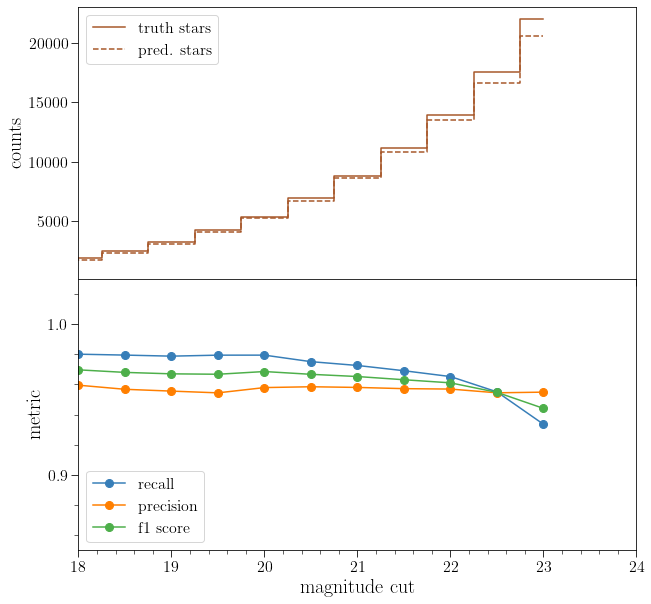

In [89]:
#fig = make_detection_figure(mag_cuts, data_coadd, ylims=(0.85, 1.03), n_gap=10)

In [105]:
data['precision']
data_coadd['precision']

tensor([0.9609, 0.9594, 0.9567, 0.9555, 0.9543, 0.9578, 0.9584, 0.9579, 0.9571,
        0.9569, 0.9544, 0.9548])

In [ ]:
def make_money_shot(
    mags,
    se,
    coadd,
    xlims=(18, 24),
    ylims=(0.7, 1.05),
    ratio=1,
    where_step="mid",
    n_gap=50,
):
    # precision / recall / f1 score
    single_exposure = se
    coadd = coadd
    # (1) precision / recall
    set_rc_params(tick_label_size=16, label_size=20)
    
    yticks = np.arange(np.round(ymin, 1), 1.1, 0.1)
    #format_plot(ax2, xlabel=r"\rm magnitude cut", ylabel="metric", yticks=yticks)
    plt.plot(mags[:, 1], single_exposure, "-o", label=r"\rm single exposure")
    plt.plot(mags[:, 1], coadd, "-o", label=r"\rm coadd")
    plt.legend(loc="lower left", prop={"size": 16})
    plt.set_xlim(xlims)
    plt.set_ylim(ylims)
    plt.yaxis.get_ticklocs(minor=True)
    plt.minorticks_on()

    return fig

In [108]:
mag_cuts2 = torch.arange(22.0, 23.5, 0.1)
mag_cuts1 = torch.full_like(mag_cuts2, fill_value=-np.inf)
mag_cuts = torch.column_stack((mag_cuts1, mag_cuts2))

In [111]:
money = compute_mag_bin_metrics(mag_cuts, truth, est)
money_coadd = compute_mag_bin_metrics(mag_cuts, truth, est_coadd)

100%|██████████| 15/15 [06:52<00:00, 27.52s/it]


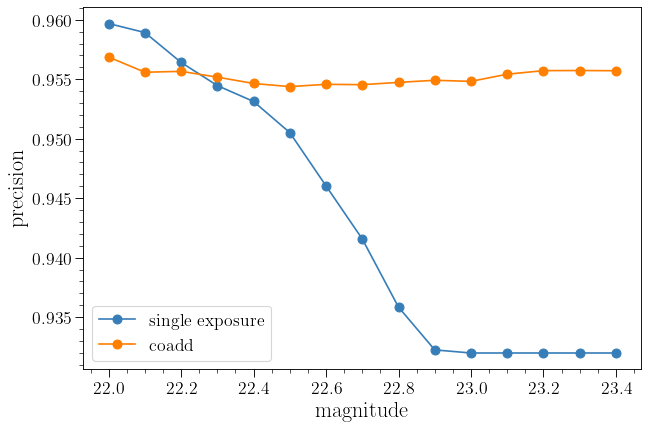

In [114]:
figure(figsize=(9, 6), dpi=80)
plt.plot(mag_cuts[:, 1], money['precision'], "-o", label=r"\rm single exposure")
plt.plot(mag_cuts[:, 1], money_coadd['precision'], "-o", label=r"\rm coadd")
plt.xlabel('magnitude')
plt.ylabel('precision')
plt.legend(loc="lower left", prop={"size": 16})
plt.minorticks_on()

## Check how single exposure data perform using model trained on coadd

Generating dataset: 100%|██████████| 100/100 [00:09<00:00, 10.88it/s]


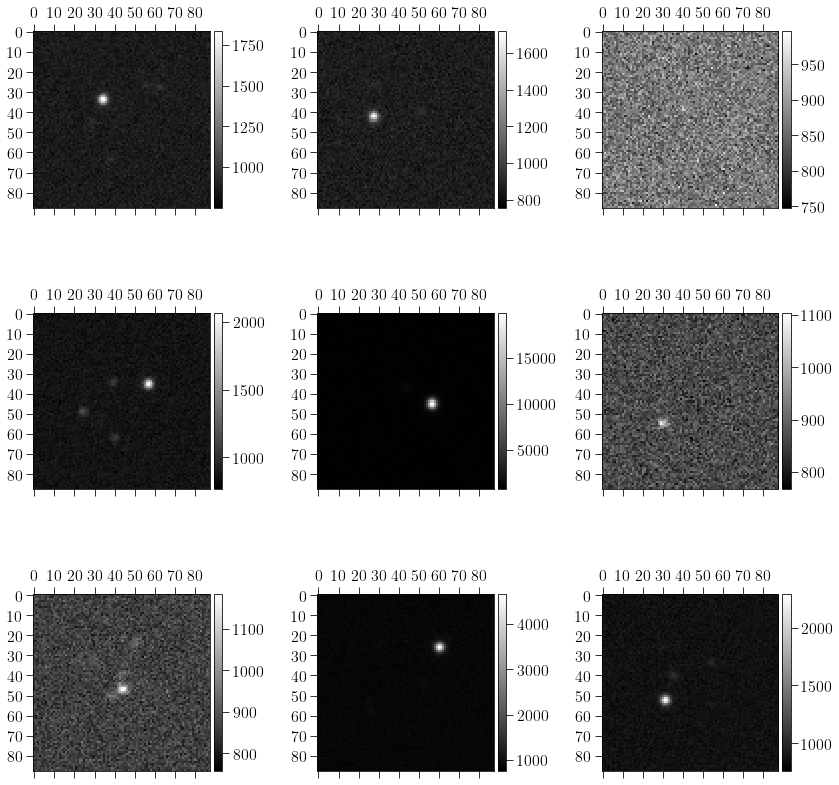

In [115]:
ds = instantiate(cfg.datasets.galsim_blends, batch_size=64, n_batches=100, num_workers=20)
from bliss.generate import generate
generate(ds, '/home/wmallory/bliss/case_studies/coadds/output/single_exposure_dataset.pt', '/home/wmallory/bliss/case_studies/coadds/output/single_exposure_dataset.png', 9, global_params=("background",))


In [117]:
sds = torch.load('/home/wmallory/bliss/case_studies/coadds/output/single_exposure_dataset.pt')
sds['images'].shape, sds['n_sources'].shape

(torch.Size([6400, 1, 88, 88]), torch.Size([6400, 10, 10]))

In [119]:
# format background (needs to be CONSTANT)
n_batches = sds['images'].shape[0]
slen = sds['images'].shape[-1]
background = rearrange(sds['background'], '1 h w -> 1 1 h w')
background = background.expand(n_batches, 1, slen, slen)

In [120]:
# run (single-exposure) model prediction 
tile_est = encoder.variational_mode(sds['images'], background)

Encoding ptiles: 640it [00:20, 30.80it/s]


In [130]:
# run (coadd) model prediction 
tile_est_coadd = encoder_coadd.variational_mode(sds['images'], background)

Encoding ptiles: 640it [00:20, 30.67it/s]


In [122]:
# load true catalog
catalog_dict = {
    "locs": sds["locs"],
    "star_log_fluxes": sds["star_log_fluxes"],
    "galaxy_bools": sds["galaxy_bools"],
    "n_sources": sds["n_sources"],
    "star_fluxes": sds['star_fluxes']
}

In [123]:
true_tile_catalog = TileCatalog(4, catalog_dict)
truth = true_tile_catalog.to_full_params()

In [124]:
est = tile_est.cpu().to_full_params() # full estimated catalog from single exposure model
est['galaxy_bools'] = torch.zeros(est.batch_size, est.max_sources, 1) # only stars, did not train classification encoder

In [125]:
# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est)

In [126]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.8766), tensor(0.9318), tensor(0.8275))

In [131]:
## Get Full Catalogs

est_coadd = tile_est_coadd.cpu().to_full_params() # full estimated catalog from single exposure model

# parameters are now per image
est_coadd.plocs.shape

est_coadd['galaxy_bools'] = torch.zeros(est_coadd.batch_size, est_coadd.max_sources, 1) # only stars, did not train classification encoder



In [132]:
## Simple metrics

# encoder
from bliss.reporting import DetectionMetrics
metrics = DetectionMetrics()(truth, est_coadd)

In [133]:
metrics['f1'], metrics['precision'], metrics['recall']

(tensor(0.4012), tensor(0.2627), tensor(0.8488))